# Importing Libraries

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

project_path = "/content/drive/MyDrive/Deepfake_Project"
os.makedirs(project_path, exist_ok=True)

print("Project folder ready.")


Project folder ready.


In [2]:
!kaggle datasets download -d xhlulu/140k-real-and-fake-faces


Dataset URL: https://www.kaggle.com/datasets/xhlulu/140k-real-and-fake-faces
License(s): other
 99% 3.72G/3.75G [00:31<00:00, 235MB/s]
100% 3.75G/3.75G [00:31<00:00, 126MB/s]


In [3]:
!unzip 140k-real-and-fake-faces.zip


Streaming output truncated to the last 5000 lines.
  inflating: real_vs_fake/real-vs-fake/valid/real/34832.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34836.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34839.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34847.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34848.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34852.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34861.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34864.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34868.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34877.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34883.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34887.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34891.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34894.jpg  
  inflating: real_vs_fake/real-vs-fake/valid/real/34904.jpg  
  inflating: real_v

In [5]:
import numpy as np
import pandas as pd
 # Note: Check if you meant plt here
import matplotlib.pyplot as plt
import os
import tensorflow as tf

# New Imports specifically for InceptionResNetV2
from tensorflow.keras.applications.inception_resnet_v2 import InceptionResNetV2, preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation, MaxPooling2D,
                                     GlobalAveragePooling2D, Dense, Flatten, Dropout)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint, ReduceLROnPlateau

In [6]:
tf.keras.backend.clear_session() #clean session

In [7]:
main_path = '/content/real_vs_fake/real-vs-fake'
train_dir = os.path.join(main_path, 'train')
valid_dir = os.path.join(main_path, 'valid')
test_dir = os.path.join(main_path, 'test')

In [8]:
print("Train_dir Subfolders: ", os.listdir(train_dir))
print("Valid_dir Subfolders: ", os.listdir(valid_dir))
print("Test_dir Subfolders: ", os.listdir(test_dir))

Train_dir Subfolders:  ['fake', 'real']
Valid_dir Subfolders:  ['fake', 'real']
Test_dir Subfolders:  ['fake', 'real']


In [9]:
import glob
images_df = {
    "folder":[],
    "image_path":[],
    "label":[]
}

for folder in os.listdir(main_path): #iterate on each train, valid and test folder
    for label in os.listdir(main_path + "/" + folder): #iterate on fake and real folders (labels)
        for img in glob.glob(main_path + "/" + folder + "/" + label + "/*.jpg"):
            images_df["folder"].append(folder)
            images_df["image_path"].append(img)
            images_df["label"].append(label)

In [10]:
images_df = pd.DataFrame(images_df)

In [11]:
df=images_df

In [12]:
import pandas as pd

valid_fake_count = 5000*2
valid_real_count = 5000*2

train_fake_count = 25000*2
train_real_count = 25000*2

test_fake_count = 5000*2
test_real_count = 5000*2

# Filter the DataFrame for each folder and image type
valid_df = df[(df['folder'] == 'valid') & (df['label'] == 'fake')][:valid_fake_count]
valid_df = pd.concat([valid_df, df[(df['folder'] == 'valid') & (df['label'] == 'real')][:valid_real_count]])

train_df = df[(df['folder'] == 'train') & (df['label'] == 'fake')][:train_fake_count]
train_df = pd.concat([train_df, df[(df['folder'] == 'train') & (df['label'] == 'real')][:train_real_count]])

test_df = df[(df['folder'] == 'test') & (df['label'] == 'fake')][:test_fake_count]
test_df = pd.concat([test_df, df[(df['folder'] == 'test') & (df['label'] == 'real')][:test_real_count]])

# Combine the DataFrames into a new one
new_df = pd.concat([valid_df, train_df, test_df])

# Reset the index
new_df.reset_index(drop=True, inplace=True)

# Display the new DataFrame



In [13]:
new_df["label"].value_counts()

,count
label,
fake,70000
real,70000


# Train and Validation Set

In [14]:
from tensorflow.keras.applications.inception_resnet_v2 import preprocess_input

# Define the path
path = '/kaggle/input/140k-real-and-fake-faces/real_vs_fake/real-vs-fake'

bs = 64
# UPDATE: InceptionResNetV2 performs best at 299x299
row, col = 299, 299

# Training set generator
# UPDATE: Using preprocess_input instead of simple 1./255 rescaling
train_datagen = ImageDataGenerator(preprocessing_function=preprocess_input, horizontal_flip=True)

training_set = train_datagen.flow_from_dataframe(dataframe=new_df[new_df['folder'] == 'train'],
                                                 directory=path,
                                                 x_col="image_path",
                                                 y_col="label",
                                                 class_mode="binary",
                                                 target_size=(row, col),
                                                 batch_size=bs,
                                                 shuffle=True)

# Validation & Test set generator
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

validation_set = val_test_datagen.flow_from_dataframe(dataframe=new_df[new_df['folder'] == 'valid'],
                                                      directory=path,
                                                      x_col="image_path",
                                                      y_col="label",
                                                      class_mode="binary",
                                                      target_size=(row, col),
                                                      batch_size=bs,
                                                      shuffle=True)

test_set = val_test_datagen.flow_from_dataframe(dataframe=new_df[new_df['folder'] == 'test'],
                                                directory=path,
                                                x_col="image_path",
                                                y_col="label",
                                                class_mode="binary",
                                                target_size=(row, col),
                                                batch_size=bs,
                                                shuffle=False)

print(training_set.class_indices)

Found 100000 validated image filenames belonging to 2 classes.
Found 20000 validated image filenames belonging to 2 classes.
Found 20000 validated image filenames belonging to 2 classes.
{'fake': 0, 'real': 1}


In [15]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.optimizers import Adam

def get_model():
    # Load InceptionResNetV2 base
    # CHANGE: input_shape is now (299, 299, 3)
    base_model = InceptionResNetV2(weights='imagenet',
                                   include_top=False,
                                   input_shape=(299, 299, 3))

    # Freeze the base model to preserve ImageNet knowledge
    base_model.trainable = False

    model = tf.keras.models.Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(1, activation='sigmoid') # Binary output: Real or Fake
    ])

    # Compile with a lower learning rate for stability
    model.compile(optimizer=Adam(learning_rate=0.0001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

    return model

# Initialize and check the new model
spoofnet = get_model()
spoofnet.summary()

219055592/219055592 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_resnet_v2             │ (None, 8, 8, 1536)     │    54,336,736 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_203         │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,126,241 (210.29 MB)

 Trainable params: 788,481 (3.01 MB)

 Non-trainable params: 54,337,760 (207.28 MB)

In [26]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class CustomScaleLayer(Layer):
    def __init__(self, scale=1.0, **kwargs):
        super(CustomScaleLayer, self).__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        shortcut, residual = inputs
        return shortcut + self.scale * residual

    def get_config(self):
        config = super(CustomScaleLayer, self).get_config()
        config.update({"scale": self.scale})
        return config


In [28]:
spoofnet = tf.keras.models.load_model(
    "/content/drive/MyDrive/Deepfake_Project/spoofnet_inception_final.keras",
    custom_objects={"CustomScaleLayer": CustomScaleLayer},
    compile=False,
    safe_mode=False
)


In [29]:
spoofnet.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


### Defining Model Checkpoints

In [30]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/Deepfake_Project/spoofnet_inception_final.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    verbose=1
)

callbacks = [checkpoint, early_stop, reduce_lr]


In [19]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class CustomScaleLayer(Layer):
    def __init__(self, scale=1.0, **kwargs):
        super(CustomScaleLayer, self).__init__(**kwargs)
        self.scale = scale

    def call(self, inputs):
        # inputs is a list: [shortcut, residual]
        shortcut, residual = inputs
        return shortcut + self.scale * residual

    def get_config(self):
        config = super(CustomScaleLayer, self).get_config()
        config.update({"scale": self.scale})
        return config


In [ ]:
spoofnet = tf.keras.models.load_model(
    "/content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5",
    custom_objects={"CustomScaleLayer": CustomScaleLayer}
)


# Training Model

In [ ]:
# Calculate steps accurately
# We add 1 to ensure that if there's a remainder (e.g., 140,005 images),
# the last few images are not ignored.
steps_per_epoch = 800
validation_steps = 200

# Start the training
hist = spoofnet.fit(
    training_set,
    validation_data=validation_set,
    callbacks=callbacks,
    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,
    epochs=10 # Increased to 10; InceptionResNet needs a bit more time to converge
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.7284 - loss: 0.5546
Epoch 1: val_accuracy improved from -inf to 0.84820, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 680s 786ms/step - accuracy: 0.7284 - loss: 0.5545 - val_accuracy: 0.8482 - val_loss: 0.3528 - learning_rate: 1.0000e-04
Epoch 2/10
763/800 ━━━━━━━━━━━━━━━━━━━━ 23s 640ms/step - accuracy: 0.8325 - loss: 0.3705

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.84820 to 0.86992, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 616s 770ms/step - accuracy: 0.8328 - loss: 0.3700 - val_accuracy: 0.8699 - val_loss: 0.3073 - learning_rate: 1.0000e-04
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.8551 - loss: 0.3345
Epoch 3: val_accuracy did not improve from 0.86992
800/800 ━━━━━━━━━━━━━━━━━━━━ 618s 768ms/step - accuracy: 0.8551 - loss: 0.3344 - val_accuracy: 0.8361 - val_loss: 0.3561 - learning_rate: 1.0000e-04
Epoch 4/10
763/800 ━━━━━━━━━━━━━━━━━━━━ 22s 614ms/step - accuracy: 0.8638 - loss: 0.3179
Epoch 4: val_accuracy improved from 0.86992 to 0.88000, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 597s 747ms/step - accuracy: 0.8638 - loss: 0.3177 - val_accuracy: 0.8800 - val_loss: 0.2901 - learning_rate: 1.0000e-04
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 615ms/step - accuracy: 0.8739 - loss: 0.2960
Epoch 5: val_accuracy improved from 0.88000 to 0.88187, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 625s 782ms/step - accuracy: 0.8739 - loss: 0.2960 - val_accuracy: 0.8819 - val_loss: 0.2802 - learning_rate: 1.0000e-04
Epoch 6/10
763/800 ━━━━━━━━━━━━━━━━━━━━ 22s 615ms/step - accuracy: 0.8795 - loss: 0.2805
Epoch 6: val_accuracy did not improve from 0.88187
800/800 ━━━━━━━━━━━━━━━━━━━━ 592s 740ms/step - accuracy: 0.8795 - loss: 0.2805 - val_accuracy: 0.8668 - val_loss: 0.3043 - learning_rate: 1.0000e-04
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 614ms/step - accuracy: 0.8857 - loss: 0.2733
Epoch 7: val_accuracy improved from 0.88187 to 0.89727, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 619s 774ms/step - accuracy: 0.8857 - loss: 0.2733 - val_accuracy: 0.8973 - val_loss: 0.2483 - learning_rate: 1.0000e-04
Epoch 8/10
339/800 ━━━━━━━━━━━━━━━━━━━━ 4:44 617ms/step - accuracy: 0.8884 - loss: 0.2693

In [ ]:
from tensorflow.keras.optimizers import Adam

spoofnet.compile(
    optimizer=Adam(learning_rate=1e-4),  # safe LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [ ]:
hist = spoofnet.fit(
    training_set,
    validation_data=validation_set,
    steps_per_epoch=800,
    validation_steps=200,
    epochs=3,
    callbacks=callbacks
)


Epoch 1/3
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 624ms/step - accuracy: 0.8863 - loss: 0.2654
Epoch 1: val_accuracy improved from -inf to 0.90062, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 687s 800ms/step - accuracy: 0.8863 - loss: 0.2654 - val_accuracy: 0.9006 - val_loss: 0.2451 - learning_rate: 1.0000e-04
Epoch 2/3
763/800 ━━━━━━━━━━━━━━━━━━━━ 24s 660ms/step - accuracy: 0.8904 - loss: 0.2637

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.90062 to 0.90234, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception.h5


800/800 ━━━━━━━━━━━━━━━━━━━━ 637s 797ms/step - accuracy: 0.8904 - loss: 0.2637 - val_accuracy: 0.9023 - val_loss: 0.2473 - learning_rate: 1.0000e-04
Epoch 3/3
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 633ms/step - accuracy: 0.8981 - loss: 0.2494
Epoch 3: val_accuracy did not improve from 0.90234
800/800 ━━━━━━━━━━━━━━━━━━━━ 633s 791ms/step - accuracy: 0.8981 - loss: 0.2494 - val_accuracy: 0.8994 - val_loss: 0.2428 - learning_rate: 1.0000e-04


In [32]:
base_model = spoofnet.layers[0]

for layer in base_model.layers[-30:]:
    layer.trainable = True


In [33]:
from tensorflow.keras.optimizers import Adam

spoofnet.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [36]:
hist_finetune = spoofnet.fit(
    training_set,
    validation_data=validation_set,
    steps_per_epoch=800,       # same as initial
    validation_steps=200,
    epochs=2,
    callbacks=callbacks
)


Epoch 1/2
800/800 ━━━━━━━━━━━━━━━━━━━━ 0s 682ms/step - accuracy: 0.8920 - loss: 0.2533
Epoch 1: val_accuracy improved from -inf to 0.92719, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception_final.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 691s 863ms/step - accuracy: 0.8920 - loss: 0.2533 - val_accuracy: 0.9272 - val_loss: 0.1822 - learning_rate: 1.0000e-05
Epoch 2/2
763/800 ━━━━━━━━━━━━━━━━━━━━ 26s 715ms/step - accuracy: 0.9261 - loss: 0.1812

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.92719 to 0.94055, saving model to /content/drive/MyDrive/Deepfake_Project/spoofnet_inception_final.keras
800/800 ━━━━━━━━━━━━━━━━━━━━ 677s 846ms/step - accuracy: 0.9263 - loss: 0.1809 - val_accuracy: 0.9405 - val_loss: 0.1501 - learning_rate: 1.0000e-05


In [37]:
spoofnet.save(
    "/content/drive/MyDrive/Deepfake_Project/spoofnet_inception_finetuned.keras"
)


In [ ]:
spoofnet.save("/content/drive/MyDrive/Deepfake_Project/spoofnet_inception_final.keras")


# plt.figure(figsize=(14,5))
plt.subplot(1,2,2)
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['train', 'val'])

plt.subplot(1,2,1)
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(['train', 'val'])
plt.show()

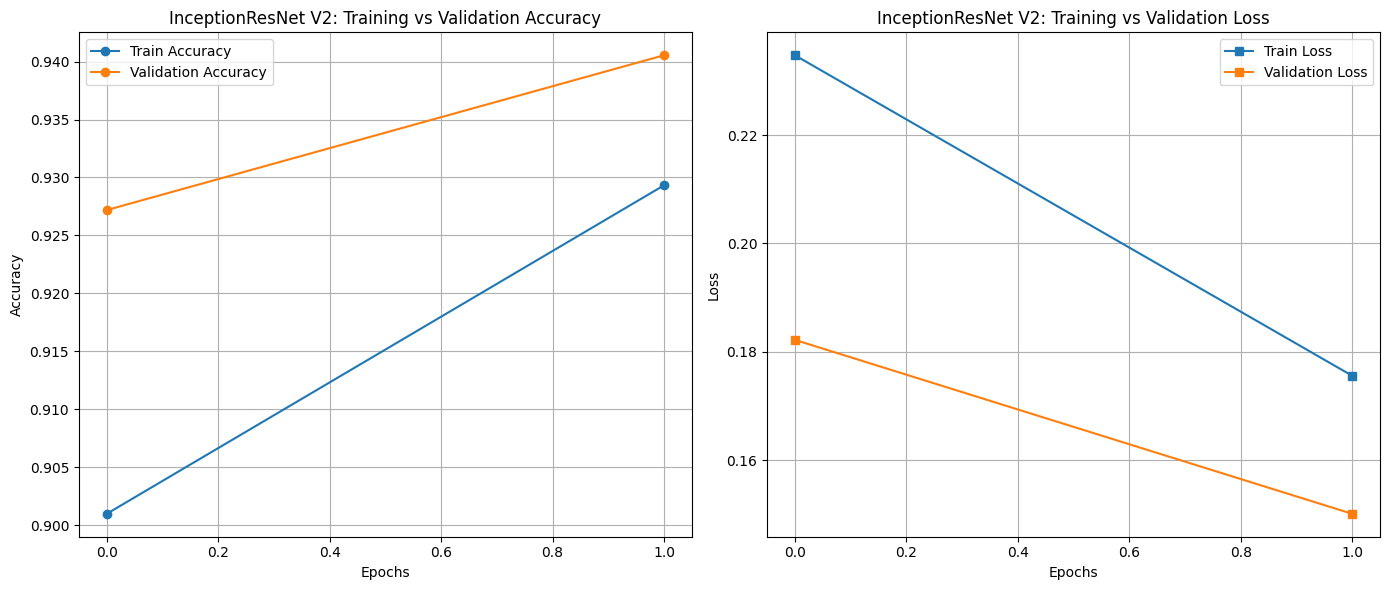

In [39]:
plt.figure(figsize=(14, 6)) # Make sure this is NOT commented out

# Plot Accuracy
plt.subplot(1, 2, 1) # Changed to 1st position for standard layout
plt.plot(hist_finetune.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(hist_finetune.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('InceptionResNet V2: Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.grid(True) # Added grid for better readability
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2) # Changed to 2nd position
plt.plot(hist_finetune.history['loss'], label='Train Loss', marker='s')
plt.plot(hist_finetune.history['val_loss'], label='Validation Loss', marker='s')
plt.title('InceptionResNet V2: Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True) # Added grid for better readability
plt.legend()

plt.tight_layout() # Ensures labels don't overlap
plt.show()

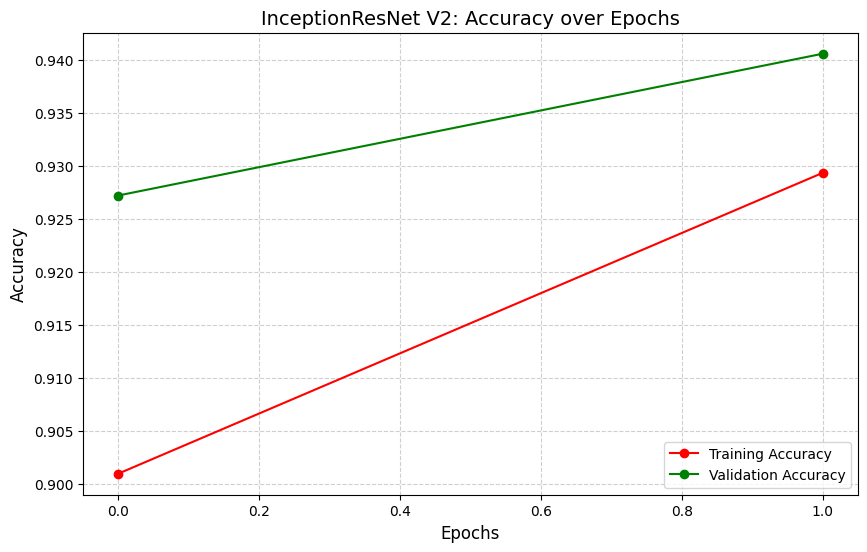

In [40]:
plt.figure(figsize=(10, 6))

# Plotting with your chosen style
plt.plot(hist_finetune.history["accuracy"], 'ro-', label="Training Accuracy")
plt.plot(hist_finetune.history["val_accuracy"], 'go-', label="Validation Accuracy")

# Adding professional touches
plt.title('InceptionResNet V2: Accuracy over Epochs', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6) # Helps reviewers see the exact %
plt.legend(loc='lower right')

plt.show()

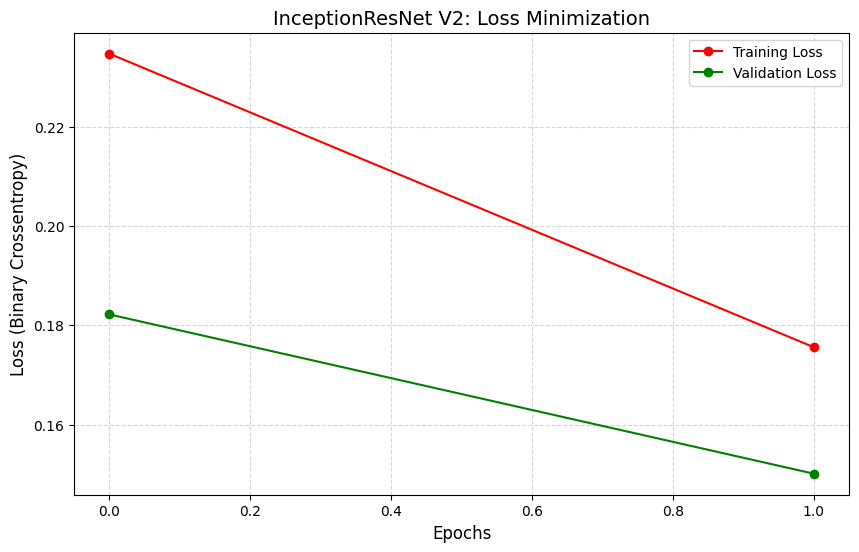

In [41]:
plt.figure(figsize=(10, 6))

# Plotting Loss with markers
plt.plot(hist_finetune.history["loss"] , 'ro-' , label = "Training Loss")
plt.plot(hist_finetune.history["val_loss"] , 'go-' , label = "Validation Loss")

# Adding details for the Reviewer
plt.title('InceptionResNet V2: Loss Minimization', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss (Binary Crossentropy)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5) # Makes it easy to see the value at each point
plt.legend()

plt.show()

# Accuracy On test set

In [42]:
# Evaluate the model on the unseen test set
# This will return the loss and the accuracy
test_loss, test_accu = spoofnet.evaluate(test_set, steps=test_set.n // test_set.batch_size)

print('-------------------------------------------')
print('InceptionResNet V2 - Final Test Results')
print('-------------------------------------------')
print('Final Test Loss: {:.4f}'.format(test_loss))
print('Final Test Accuracy: {:.2f}%'.format(test_accu * 100))
print('-------------------------------------------')

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


312/312 ━━━━━━━━━━━━━━━━━━━━ 202s 648ms/step - accuracy: 0.9421 - loss: 0.1484
-------------------------------------------
InceptionResNet V2 - Final Test Results
-------------------------------------------
Final Test Loss: 0.1591
Final Test Accuracy: 93.73%
-------------------------------------------


In [43]:
val_loss, val_acc = spoofnet.evaluate(validation_set)
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)


313/313 ━━━━━━━━━━━━━━━━━━━━ 207s 661ms/step - accuracy: 0.9387 - loss: 0.1531
Validation Accuracy: 0.9395999908447266
Validation Loss: 0.1523965448141098


In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/Deepfake_Project'))


['spoofnet_inception.h5', 'spoofnet_inception_final.keras']


# Confusion Matrix and Classification Report

313/313 ━━━━━━━━━━━━━━━━━━━━ 224s 677ms/step
Classification Report
              precision    recall  f1-score   support

        Real       0.93      0.94      0.94     10000
        Fake       0.94      0.93      0.94     10000

    accuracy                           0.94     20000
   macro avg       0.94      0.94      0.94     20000
weighted avg       0.94      0.94      0.94     20000



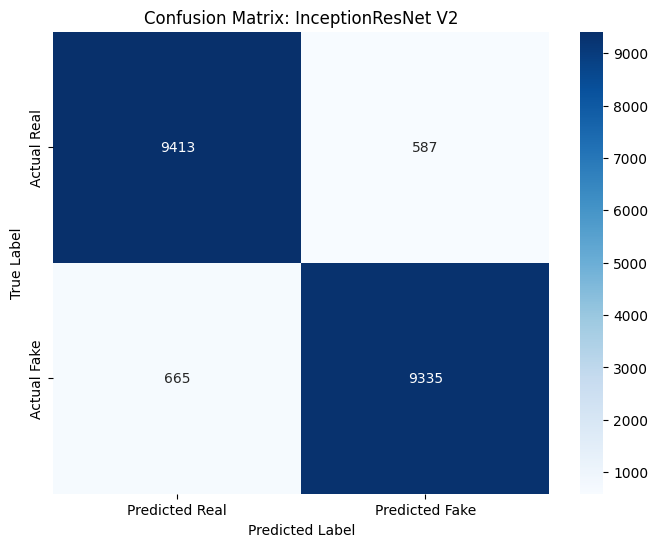

In [44]:
# 1. Re-initialize the test set WITHOUT shuffling so the order matches the labels
test_set.reset()

# 2. Get predictions
y_pred_probs = spoofnet.predict(test_set, steps=len(test_set))
# If your Sigmoid says 0.9, it's 'Fake' (1). If < 0.5, it's 'Real' (0).
y_pred = (y_pred_probs > 0.5).astype(int)

# 3. Get the true labels
y_true = test_set.classes

# 4. Generate the Matrix and Report
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns # Seaborn makes the matrix look much better

cm = confusion_matrix(y_true, y_pred)
print('Classification Report')
print(classification_report(y_true, y_pred, target_names=['Real', 'Fake']))

# 5. Professional Heatmap Plot
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Real', 'Predicted Fake'],
            yticklabels=['Actual Real', 'Actual Fake'])
plt.title('Confusion Matrix: InceptionResNet V2')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

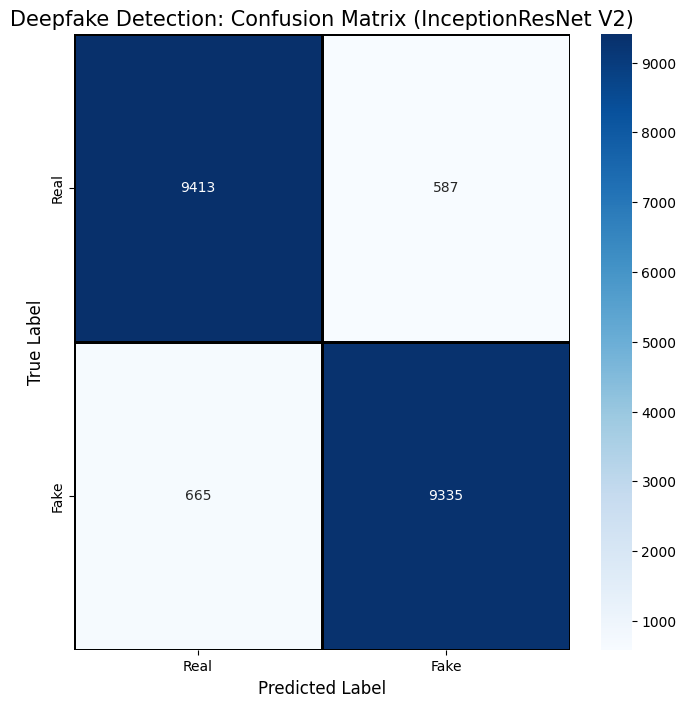

In [45]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# Using the class names directly makes the chart self-explanatory
names = ['Real', 'Fake']

# Create DataFrame with names instead of 0 and 1
cm_df = pd.DataFrame(cm, index=names, columns=names)

plt.figure(figsize=(8, 8))
sns.heatmap(cm_df,
            cmap="Blues",
            linecolor='black',
            linewidth=1,
            annot=True,
            fmt='d') # 'd' stands for decimal integer

plt.title('Deepfake Detection: Confusion Matrix (InceptionResNet V2)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

In [ ]:
import os

# This lists everything in the input directory
for dirname, _, filenames in os.walk('/kaggle/input'):
    # We only want to see the first few levels so we don't get a million filenames
    depth = dirname.count(os.path.sep)
    if depth < 6:
        print(f"Folder: {dirname}")

Folder: /kaggle/input


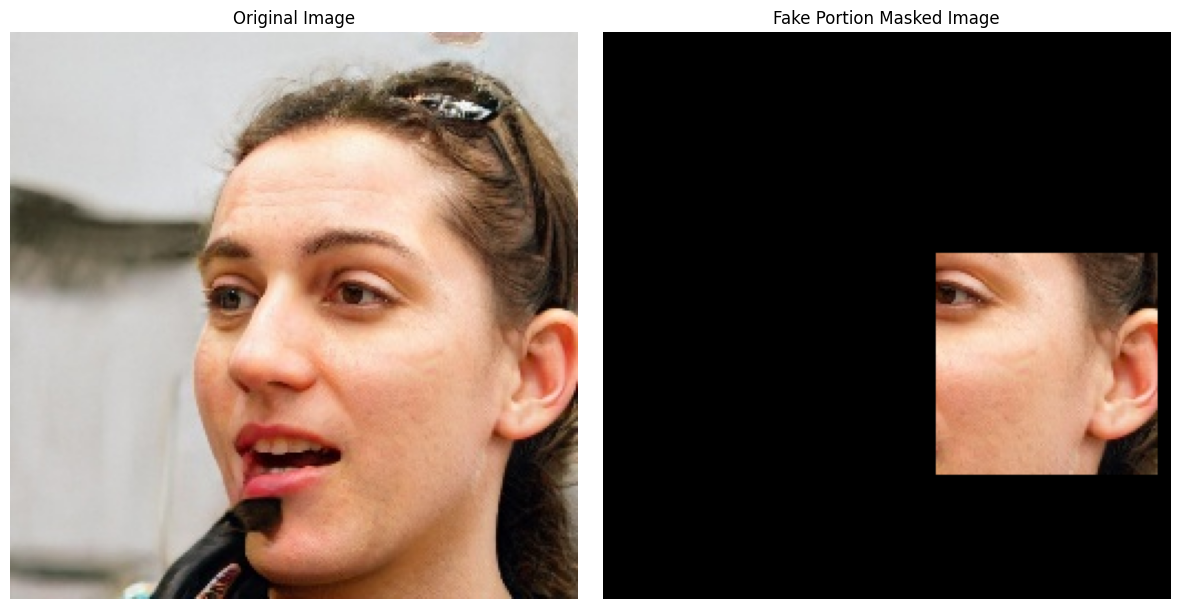

In [48]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image (replace 'entire_image.jpg' with your image file)
image = cv2.imread('/content/real_vs_fake/real-vs-fake/test/fake/00F8LKY6JC.jpg')

# Create a binary mask (replace these with your specific criteria)
fake_face_mask = np.zeros_like(image[:, :, 0], dtype=np.uint8)
fake_face_mask[100:200, 150:250] = 255  # Example: a rectangle region as fake face

# Apply the mask to the original image
masked_image = cv2.bitwise_and(image, image, mask=fake_face_mask)

# Display the original image and the masked image using Matplotlib
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot original image
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot masked image
axes[1].imshow(cv2.cvtColor(masked_image, cv2.COLOR_BGR2RGB))
axes[1].set_title('Fake Portion Masked Image')
axes[1].axis('off')

plt.tight_layout()
plt.show()


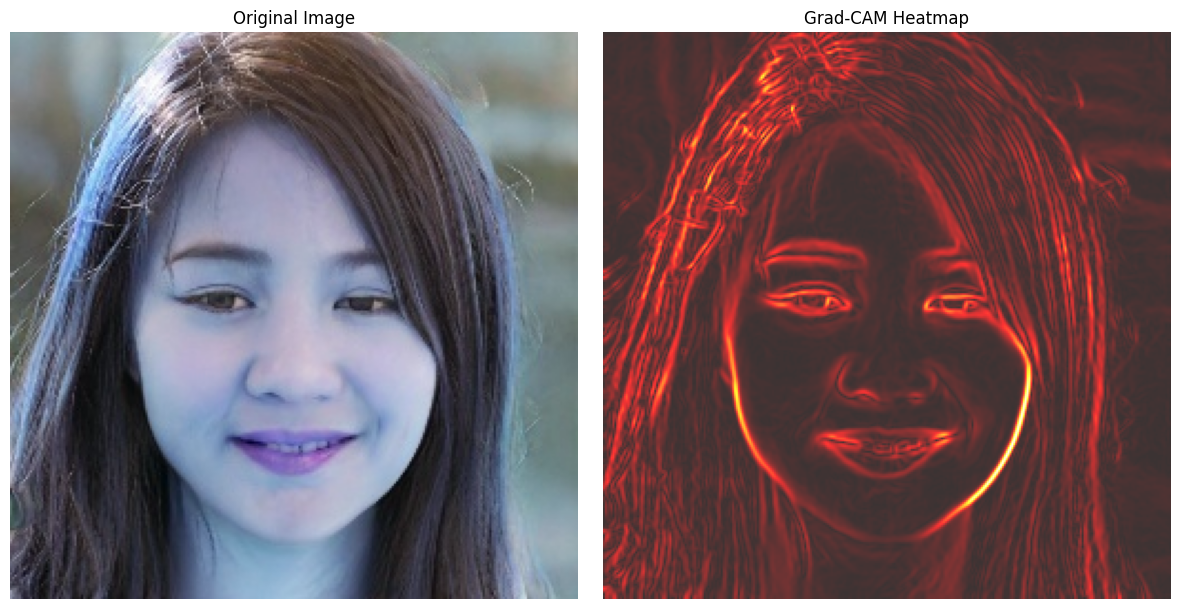

In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def grad_cam(img_path):
    # Load the image
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (299, 299))  # Resize to match input size of most pre-trained models

    # Convert image to grayscale
    gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Compute gradient magnitude
    sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=5)
    sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=5)
    gradient_magnitude = np.sqrt(sobelx**2 + sobely**2)

    # Normalize gradient magnitude to range [0, 1]
    gradient_magnitude /= gradient_magnitude.max()

    return gradient_magnitude

# Path to the image
img_path = '/content/real_vs_fake/real-vs-fake/test/fake/00276TOPP4.jpg'  # Replace with your image file


# Compute Grad-CAM
heatmap = grad_cam(img_path)

# Plot the original image and the Grad-CAM heatmap
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot original image
axes[0].imshow(cv2.imread(img_path))
axes[0].set_title('Original Image')
axes[0].axis('off')

# Plot Grad-CAM heatmap
axes[1].imshow(heatmap, cmap='hot', alpha=0.8)
axes[1].set_title('Grad-CAM Heatmap')
axes[1].axis('off')

plt.tight_layout()
plt.show()


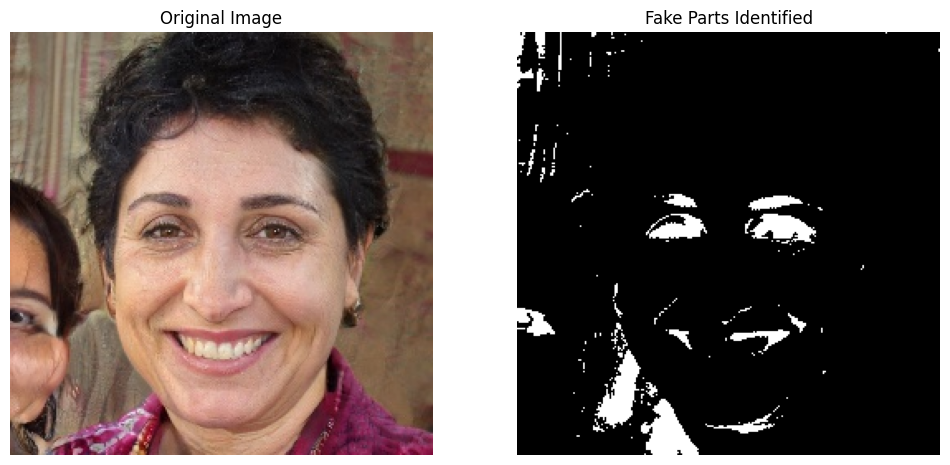

In [50]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your image
image = cv2.imread('/content/real_vs_fake/real-vs-fake/test/fake/00QKZTHTLF.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply adaptive thresholding to binarize the image
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert the binary image to get black background and white foreground
binary = cv2.bitwise_not(binary)

# Find contours in the binary image
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a mask for the fake parts of the image
fake_mask = np.zeros_like(binary)

# Iterate through each contour
for contour in contours:
    # Compute the area of the contour
    area = cv2.contourArea(contour)
    # If the area is below a certain threshold, consider it as fake
    if area < 1000:  # Adjust this threshold according to your image
        # Draw the contour on the mask
        cv2.drawContours(fake_mask, [contour], -1, (255), thickness=cv2.FILLED)

# Plot the original image and the identified fake parts
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(fake_mask, cmap='gray')
plt.title('Fake Parts Identified')
plt.axis('off')

plt.show()


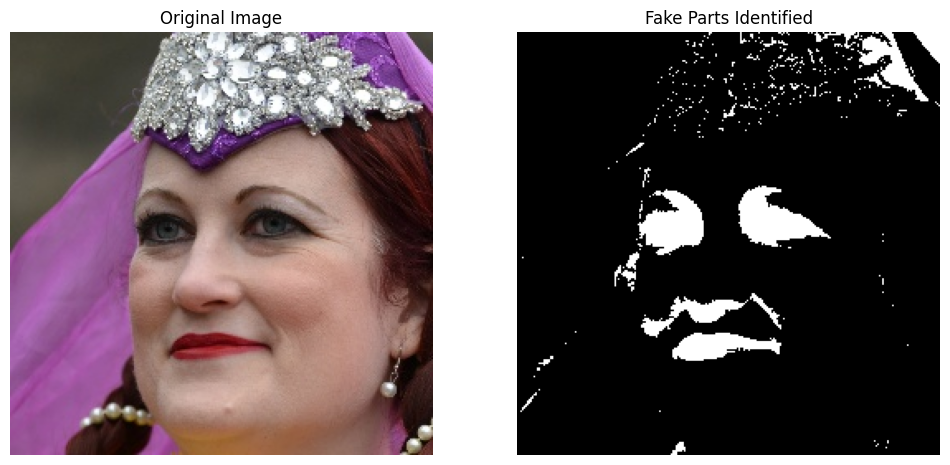

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your image
image = cv2.imread('/content/real_vs_fake/real-vs-fake/test/real/00170.jpg')

# Convert the image to grayscale
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply adaptive thresholding to binarize the image
_, binary = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Invert the binary image to get black background and white foreground
binary = cv2.bitwise_not(binary)

# Find contours in the binary image
contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Create a mask for the fake parts of the image
fake_mask = np.zeros_like(binary)

# Iterate through each contour
for contour in contours:
    # Compute the area of the contour
    area = cv2.contourArea(contour)
    # If the area is below a certain threshold, consider it as fake
    if area < 1000:  # Adjust this threshold according to your image
        # Draw the contour on the mask
        cv2.drawContours(fake_mask, [contour], -1, (255), thickness=cv2.FILLED)

# Plot the original image and the identified fake parts
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(fake_mask, cmap='gray')
plt.title('Fake Parts Identified')
plt.axis('off')

plt.show()


In [ ]:
import pandas as pd
history_df = pd.DataFrame(hist.history)
history_df.to_csv('training_history.csv', index=False)
# Download this CSV too!